In [14]:
# ============================================================
# ✅ IMPORTS
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import zipfile

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import FileLink, display

In [15]:
# ============================================================
# ✅ PATHS
# ============================================================
TRAIN_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train"
OUTPUT_DIR = "/kaggle/working/densenet169_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found: {TRAIN_DIR}")


# ============================================================
# ✅ DATA GENERATORS
# ============================================================
batch_size = 16
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.20,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Train samples: 4002
Validation samples: 998


In [16]:
# ============================================================
# ✅ MODEL: DENSENET169
# ============================================================
base_model = DenseNet169(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze first 75% layers safely
total_layers = len(base_model.layers)
freeze_until = int(total_layers * 0.75)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
for layer in base_model.layers[freeze_until:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu",
          kernel_regularizer=regularizers.l2(8e-4))(x)
x = Dropout(0.45)(x)

x = Dense(128, activation="relu",
          kernel_regularizer=regularizers.l2(8e-4))(x)
x = Dropout(0.35)(x)

output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


# ============================================================
# ✅ COMPILE
# ============================================================
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 13,109,188 (50.01 MB)

 Trainable params: 4,827,588 (18.42 MB)

 Non-trainable params: 8,281,600 (31.59 MB)

In [18]:
# ============================================================
# ✅ CALLBACKS
# ============================================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# ✅ TRAINING
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 157s 625ms/step - accuracy: 0.7321 - loss: 1.1225 - val_accuracy: 0.8016 - val_loss: 0.9100 - learning_rate: 3.0000e-04
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 293ms/step - accuracy: 0.8888 - loss: 0.6425 - val_accuracy: 0.8657 - val_loss: 0.6521 - learning_rate: 3.0000e-04
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 289ms/step - accuracy: 0.9229 - loss: 0.5313 - val_accuracy: 0.8727 - val_loss: 0.8231 - learning_rate: 3.0000e-04
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 76s 304ms/step - accuracy: 0.9112 - loss: 0.5472 - val_accuracy: 0.8968 - val_loss: 0.7967 - learning_rate: 3.0000e-04
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 288ms/step - accuracy: 0.9465 - loss: 0.4553 - val_accuracy: 0.9168 - val_loss: 0.5732 - learning_rate: 3.0000e-04
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 293ms/step - accuracy: 0.9516 - loss: 0.4252 - val_accuracy: 0.8357 - val_loss: 1.3539 - learning_rate: 3.0000e-04
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━

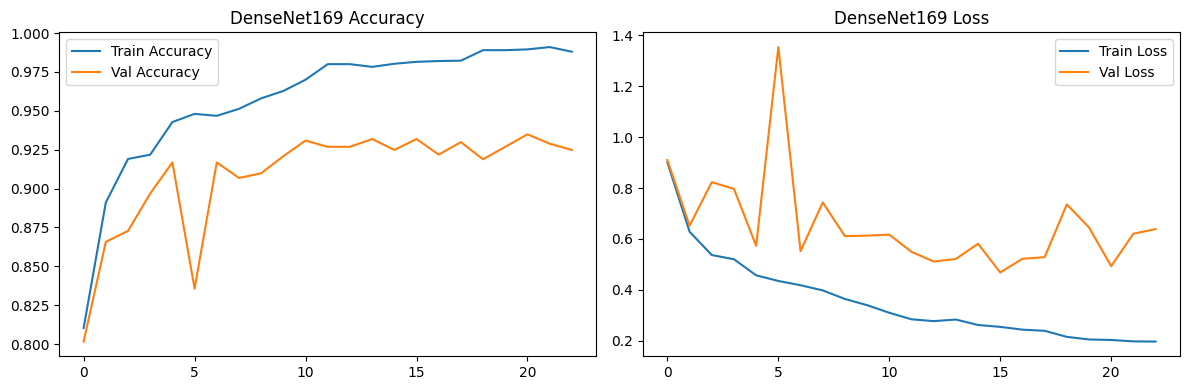

✅ Training curves saved.


In [20]:
# ============================================================
# ✅ TRAINING CURVES
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("DenseNet169 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("DenseNet169 Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
plt.show()

print("✅ Training curves saved.")

In [21]:
# ============================================================
# ✅ EVALUATION
# ============================================================
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")


# ============================================================
# ✅ METRICS
# ============================================================
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
f1   = f1_score(y_true, y_pred, average="macro")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Validation Loss: 0.4294
Validation Accuracy: 94.29%

Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       229
  meningioma       0.90      0.89      0.90       265
    no_tumor       0.93      0.99      0.95       213
   pituitary       0.96      0.94      0.95       291

    accuracy                           0.94       998
   macro avg       0.94      0.94      0.94       998
weighted avg       0.94      0.94      0.94       998



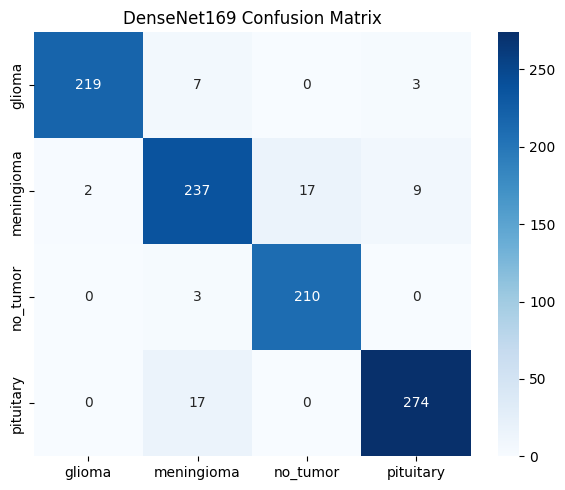

✅ Confusion matrix saved.


In [22]:
# ============================================================
# ✅ CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("DenseNet169 Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()

np.save(os.path.join(OUTPUT_DIR, "confusion_matrix.npy"), cm)

print("✅ Confusion matrix saved.")

In [24]:
# ============================================================
# ✅ SAVE METRICS & PREDICTIONS
# ============================================================
report_df = pd.DataFrame(
    classification_report(y_true, y_pred,
                          target_names=class_names,
                          output_dict=True)
).transpose()

report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report.csv"))

summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [acc, prec, rec, f1]
})
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"), index=False)

pred_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred
})
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions.csv"), index=False)

print("✅ Metrics and predictions saved.")


# ============================================================
# ✅ ZIP RESULTS
# ============================================================
zip_path = "/kaggle/working/densenet169_results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), file)

print(f"\n📦 All results saved to: {zip_path}")
display(FileLink(zip_path))

✅ Metrics and predictions saved.

📦 All results saved to: /kaggle/working/densenet169_results.zip


/kaggle/working/densenet169_results.zip